# 05 — Model Monitoring
Παρακολούθηση σταθερότητας μοντέλου με PSI (Population Stability Index)
και CSI (Characteristic Stability Index).
Προσομοίωση χρονικής μετατόπισης δεδομένων (Data Drift).

## 1. Εισαγωγή βιβλιοθηκών

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print("Βιβλιοθήκες φορτώθηκαν επιτυχώς.")

Βιβλιοθήκες φορτώθηκαν επιτυχώς.


## 2. Φόρτωση δεδομένων και μοντέλου

In [13]:
DATA_DIR = '../data/processed'

X_train       = np.load(f'{DATA_DIR}/X_train.npy')
X_test        = np.load(f'{DATA_DIR}/X_test.npy')
y_train       = np.load(f'{DATA_DIR}/y_train.npy')
y_test        = np.load(f'{DATA_DIR}/y_test.npy')
feature_names = np.load(f'{DATA_DIR}/feature_names.npy', allow_pickle=True)

xgb_model = XGBClassifier()
xgb_model.load_model('../data/models/xgb_model.json')

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Δεδομένα και μοντέλο φορτώθηκαν επιτυχώς.")

Train: (6902, 23), Test: (1480, 23)
Δεδομένα και μοντέλο φορτώθηκαν επιτυχώς.


## 3. Προσομοίωση Data Drift
Δημιουργία "future" dataset που προσομοιώνει αλλαγή οικονομικών συνθηκών.

In [14]:
np.random.seed(42)

X_future = X_test.copy().astype(float)

# Gaussian noise σε όλα τα χαρακτηριστικά
# Προσομοίωση επιδείνωσης οικονομικών συνθηκών
for i, feature in enumerate(feature_names):
    std = X_test[:, i].std()
    
    if feature == 'ExternalRiskEstimate':
        # Μείωση score — αρνητικό mean
        X_future[:, i] += np.random.normal(-0.5 * std, 0.15 * std, size=len(X_future))

    elif feature == 'NetFractionRevolvingBurden':
        # Αύξηση χρέους — θετικό mean
        X_future[:, i] += np.random.normal(0.5 * std, 0.15 * std, size=len(X_future))

    elif feature == 'AverageMInFile':
        # Νεότερο ιστορικό — αρνητικό mean
        X_future[:, i] += np.random.normal(-0.4 * std, 0.15 * std, size=len(X_future))

    else:
        # Ελαφρύ noise σε όλα τα υπόλοιπα
        X_future[:, i] += np.random.normal(0, 0.1 * std, size=len(X_future))


ext_idx = list(feature_names).index('ExternalRiskEstimate')
net_idx = list(feature_names).index('NetFractionRevolvingBurden')
avg_idx = list(feature_names).index('AverageMInFile')

print("Future dataset δημιουργήθηκε με Gaussian Noise.")
print(f"ExternalRiskEstimate — Πριν: {X_test[:, ext_idx].mean():.1f}, Μετά: {X_future[:, ext_idx].mean():.1f}")
print(f"NetFractionRevolvingBurden — Πριν: {X_test[:, net_idx].mean():.1f}, Μετά: {X_future[:, net_idx].mean():.1f}")
print(f"AverageMInFile — Πριν: {X_test[:, avg_idx].mean():.1f}, Μετά: {X_future[:, avg_idx].mean():.1f}")

Future dataset δημιουργήθηκε με Gaussian Noise.
ExternalRiskEstimate — Πριν: 72.0, Μετά: 67.2
NetFractionRevolvingBurden — Πριν: 33.7, Μετά: 48.2
AverageMInFile — Πριν: 78.6, Μετά: 65.0


## 4. PSI — Population Stability Index
Έλεγχος αν η κατανομή των scores άλλαξε σημαντικά.
Όρια: PSI < 0.10 → σταθερό, 0.10-0.25 → παρακολούθηση, > 0.25 → αστάθεια

In [15]:
def calculate_psi(expected, actual, bins=10):
    breakpoints = np.linspace(0, 1, bins + 1)
    expected_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_pct   = np.histogram(actual,   bins=breakpoints)[0] / len(actual)
    
    # floor στο 0.0001 για αποφυγή log(0) — μικρό αρκετά ώστε να μην επηρεάζει το PSI
    expected_pct = np.where(expected_pct == 0, 0.0001, expected_pct)
    actual_pct   = np.where(actual_pct   == 0, 0.0001, actual_pct)
    
    psi = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return psi

# Scores πριν και μετά
scores_now    = xgb_model.predict_proba(X_test)[:, 1]
scores_future = xgb_model.predict_proba(X_future)[:, 1]

psi = calculate_psi(scores_now, scores_future)

print(f"PSI: {psi:.4f}")
if psi < 0.10:
    print("→ Σταθερό μοντέλο")
elif psi < 0.25:
    print("→ Παρακολούθηση απαιτείται")
else:
    print("→ Αστάθεια — επανεκπαίδευση απαιτείται")

PSI: 0.2099
→ Παρακολούθηση απαιτείται


In [16]:
def calculate_csi(expected, actual, bins=10):
    breakpoints = np.linspace(
        min(expected.min(), actual.min()),
        max(expected.max(), actual.max()),
        bins + 1
    )
    expected_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_pct   = np.histogram(actual,   bins=breakpoints)[0] / len(actual)
    
    expected_pct = np.where(expected_pct == 0, 0.0001, expected_pct)
    actual_pct   = np.where(actual_pct   == 0, 0.0001, actual_pct)
    
    csi = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return csi

# CSI για κάθε feature
csi_values = []
for i, feature in enumerate(feature_names):
    csi = calculate_csi(X_test[:, i], X_future[:, i])
    csi_values.append({'Feature': feature, 'CSI': csi})

csi_df = pd.DataFrame(csi_values).sort_values('CSI', ascending=False)

print("CSI ανά χαρακτηριστικό:")
print(csi_df.to_string(index=False))

CSI ανά χαρακτηριστικό:
                           Feature      CSI
          MaxDelq2PublicRecLast12M 0.919760
                       MaxDelqEver 0.906394
        NetFractionRevolvingBurden 0.795892
              ExternalRiskEstimate 0.489043
                    AverageMInFile 0.163167
                      NumInqLast6M 0.069869
             NumInqLast6Mexcl7days 0.038158
             PercentTradesWBalance 0.015423
          NetFractionInstallBurden 0.013779
            NumTradesOpeninLast12M 0.011117
NumBank2NatlTradesWHighUtilization 0.007965
        NumRevolvingTradesWBalance 0.007076
       NumTrades60Ever2DerogPubRec 0.006718
              PercentInstallTrades 0.005659
          NumInstallTradesWBalance 0.005612
      MSinceMostRecentInqexcl7days 0.004593
                    NumTotalTrades 0.003333
             NumSatisfactoryTrades 0.002589
              MSinceMostRecentDelq 0.002344
            PercentTradesNeverDelq 0.002192
             MSinceOldestTradeOpen 0.000456
        

## 5. PSI — Population Stability Index
Έλεγχος αν η κατανομή των scores άλλαξε σημαντικά.
Όρια: PSI < 0.10 → σταθερό, 0.10-0.25 → παρακολούθηση, > 0.25 → αστάθεια

### 5.1 Οπτικοποίηση CSI

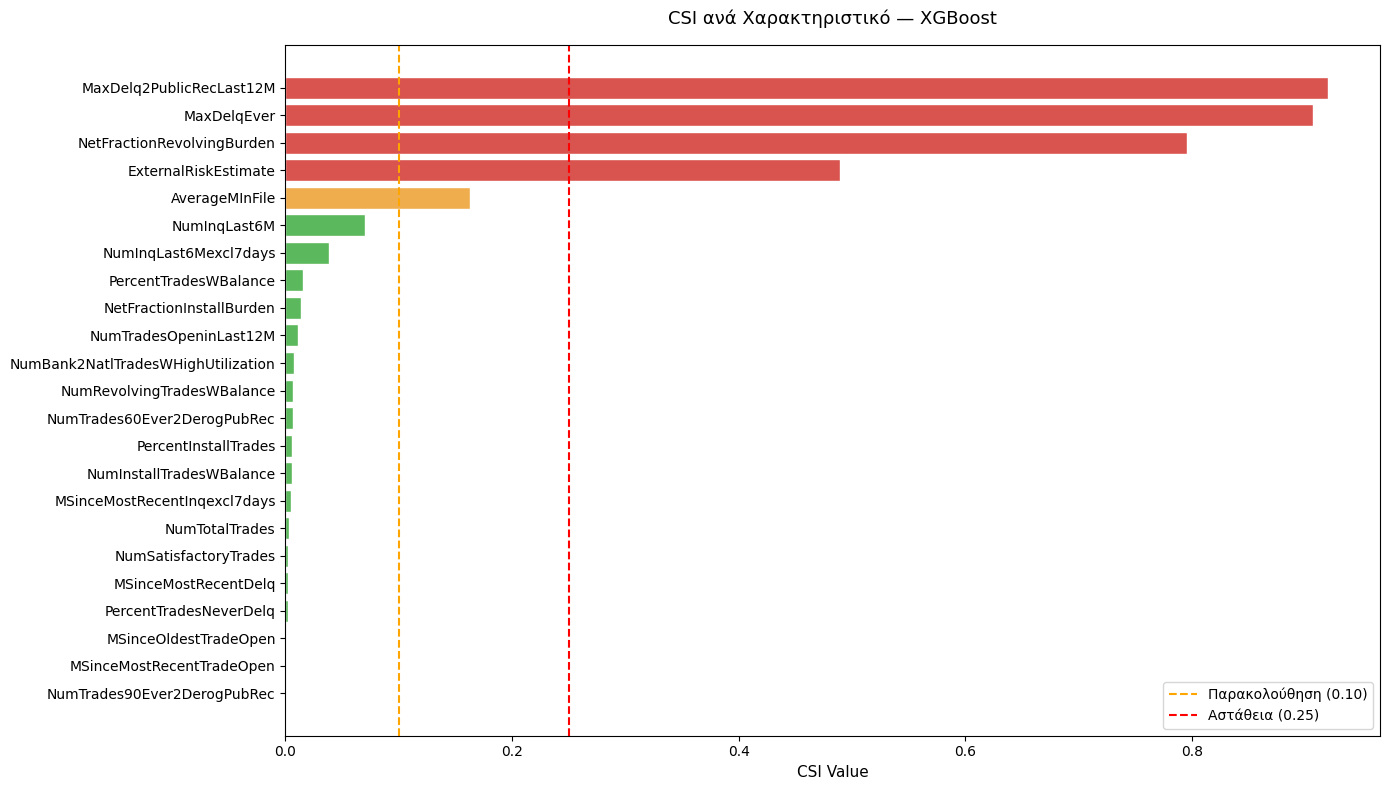

Αποθηκεύτηκε: figures/13_csi.png


In [17]:
fig, ax = plt.subplots(figsize=(14, 8))

colors = ['#d9534f' if x > 0.25 else '#f0ad4e' if x > 0.10 else '#5cb85c' 
          for x in csi_df['CSI']]

bars = ax.barh(csi_df['Feature'][::-1], csi_df['CSI'][::-1], 
               color=colors[::-1], edgecolor='white')

ax.axvline(x=0.10, color='orange', linestyle='--', linewidth=1.5, label='Παρακολούθηση (0.10)')
ax.axvline(x=0.25, color='red', linestyle='--', linewidth=1.5, label='Αστάθεια (0.25)')
ax.set_xlabel('CSI Value', fontsize=11)
ax.set_title('CSI ανά Χαρακτηριστικό — XGBoost', fontsize=13, pad=15)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../figures/13_csi.png', dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: figures/13_csi.png")

## 6. Monitoring FFNN — Επίδειξη Αυξημένης Δυσκολίας

In [18]:
from tensorflow import keras

ffnn_model = keras.models.load_model('../data/models/ffnn_model.keras')
scaler = joblib.load('../data/processed/scaler.pkl')

# Scaling του future dataset
X_future_scaled = scaler.transform(X_future)

# PSI για FFNN
scores_ffnn_now    = ffnn_model.predict(X_test_scaled if 'X_test_scaled' in dir() 
                     else scaler.transform(X_test), verbose=0).flatten()
scores_ffnn_future = ffnn_model.predict(X_future_scaled, verbose=0).flatten()

psi_ffnn = calculate_psi(scores_ffnn_now, scores_ffnn_future)

print(f"PSI XGBoost: {psi:.4f}")
print(f"PSI FFNN:    {psi_ffnn:.4f}")
print()
print("Πρόσθετες δυσκολίες monitoring για FFNN:")
print("  - Δεν υπάρχει TreeExplainer → SHAP πολύ πιο αργό")
print("  - Εκατομμύρια παράμετροι → δύσκολο να εντοπιστεί η αιτία αστάθειας")
print("  - Απαιτείται πιο συχνή παρακολούθηση λόγω μαύρης κουτί φύσης")

PSI XGBoost: 0.2099
PSI FFNN:    0.2206

Πρόσθετες δυσκολίες monitoring για FFNN:
  - Δεν υπάρχει TreeExplainer → SHAP πολύ πιο αργό
  - Εκατομμύρια παράμετροι → δύσκολο να εντοπιστεί η αιτία αστάθειας
  - Απαιτείται πιο συχνή παρακολούθηση λόγω μαύρης κουτί φύσης


### 6.1 PSI Scenarios — FFNN
Σύγκριση PSI σε τρία σενάρια οικονομικής επιδείνωσης.

In [19]:
scenarios = {
    'Ήπια επιδείνωση': (0.2, 0.2, 0.15),
    'Μέτρια επιδείνωση': (0.5, 0.5, 0.4),
    'Σοβαρή επιδείνωση': (0.9, 0.9, 0.7)
}

psi_results_ffnn = []

for scenario_name, (ext_factor, net_factor, avg_factor) in scenarios.items():
    np.random.seed(42)
    X_scenario = X_test.copy().astype(float)
    
    for i, feature in enumerate(feature_names):
        std = X_test[:, i].std()
        if feature == 'ExternalRiskEstimate':
            X_scenario[:, i] += np.random.normal(-ext_factor * std, 0.15 * std, size=len(X_scenario))
        elif feature == 'NetFractionRevolvingBurden':
            X_scenario[:, i] += np.random.normal(net_factor * std, 0.15 * std, size=len(X_scenario))
        elif feature == 'AverageMInFile':
            X_scenario[:, i] += np.random.normal(-avg_factor * std, 0.15 * std, size=len(X_scenario))
        else:
            X_scenario[:, i] += np.random.normal(0, 0.1 * std, size=len(X_scenario))
    
    X_scenario_scaled = scaler.transform(X_scenario)
    scores_scenario_ffnn = ffnn_model.predict(X_scenario_scaled, verbose=0).flatten()
    psi_scenario_ffnn = calculate_psi(scores_ffnn_now, scores_scenario_ffnn)
    psi_results_ffnn.append({'Σενάριο': scenario_name, 'PSI': psi_scenario_ffnn})
    print(f"{scenario_name}: PSI = {psi_scenario_ffnn:.4f}")

print()
print("Baseline (κανένα drift): PSI = 0.0000")


psi_results_ffnn = []

for scenario_name, (ext_factor, net_factor, avg_factor) in scenarios.items():
    np.random.seed(42)
    X_scenario = X_test.copy().astype(float)
    
    for i, feature in enumerate(feature_names):
        std = X_test[:, i].std()
        if feature == 'ExternalRiskEstimate':
            X_scenario[:, i] += np.random.normal(-ext_factor * std, 0.15 * std, size=len(X_scenario))
        elif feature == 'NetFractionRevolvingBurden':
            X_scenario[:, i] += np.random.normal(net_factor * std, 0.15 * std, size=len(X_scenario))
        elif feature == 'AverageMInFile':
            X_scenario[:, i] += np.random.normal(-avg_factor * std, 0.15 * std, size=len(X_scenario))
        else:
            X_scenario[:, i] += np.random.normal(0, 0.1 * std, size=len(X_scenario))
    
    X_scenario_scaled = scaler.transform(X_scenario)
    scores_scenario_ffnn = ffnn_model.predict(X_scenario_scaled, verbose=0).flatten()
    psi_scenario_ffnn = calculate_psi(scores_ffnn_now, scores_scenario_ffnn)
    psi_results_ffnn.append({'Σενάριο': scenario_name, 'PSI': psi_scenario_ffnn})
    print(f"{scenario_name}: PSI = {psi_scenario_ffnn:.4f}")

print()
print("Baseline (κανένα drift): PSI = 0.0000")

Ήπια επιδείνωση: PSI = 0.0363
Μέτρια επιδείνωση: PSI = 0.2206
Σοβαρή επιδείνωση: PSI = 0.6525

Baseline (κανένα drift): PSI = 0.0000
Ήπια επιδείνωση: PSI = 0.0363
Μέτρια επιδείνωση: PSI = 0.2206
Σοβαρή επιδείνωση: PSI = 0.6525

Baseline (κανένα drift): PSI = 0.0000


### 6.2 CSI — FFNN
Σταθερότητα κάθε χαρακτηριστικού ξεχωριστά.
Το CSI υπολογίζεται εξίσου εύκολα αλλά η ερμηνεία είναι δυσκολότερη
χωρίς TreeExplainer.

In [20]:
# CSI για FFNN — ίδιος υπολογισμός με XGBoost
csi_values_ffnn = []
for i, feature in enumerate(feature_names):
    csi = calculate_csi(X_test[:, i], X_future[:, i])
    csi_values_ffnn.append({'Feature': feature, 'CSI': csi})

csi_df_ffnn = pd.DataFrame(csi_values_ffnn).sort_values('CSI', ascending=False)

print("CSI ανά χαρακτηριστικό — FFNN:")
print(csi_df_ffnn.to_string(index=False))

CSI ανά χαρακτηριστικό — FFNN:
                           Feature      CSI
          MaxDelq2PublicRecLast12M 0.919760
                       MaxDelqEver 0.906394
        NetFractionRevolvingBurden 0.795892
              ExternalRiskEstimate 0.489043
                    AverageMInFile 0.163167
                      NumInqLast6M 0.069869
             NumInqLast6Mexcl7days 0.038158
             PercentTradesWBalance 0.015423
          NetFractionInstallBurden 0.013779
            NumTradesOpeninLast12M 0.011117
NumBank2NatlTradesWHighUtilization 0.007965
        NumRevolvingTradesWBalance 0.007076
       NumTrades60Ever2DerogPubRec 0.006718
              PercentInstallTrades 0.005659
          NumInstallTradesWBalance 0.005612
      MSinceMostRecentInqexcl7days 0.004593
                    NumTotalTrades 0.003333
             NumSatisfactoryTrades 0.002589
              MSinceMostRecentDelq 0.002344
            PercentTradesNeverDelq 0.002192
             MSinceOldestTradeOpen 0.000456
 

### 6.3 Σύγκριση PSI & CSI — XGBoost vs FFNN

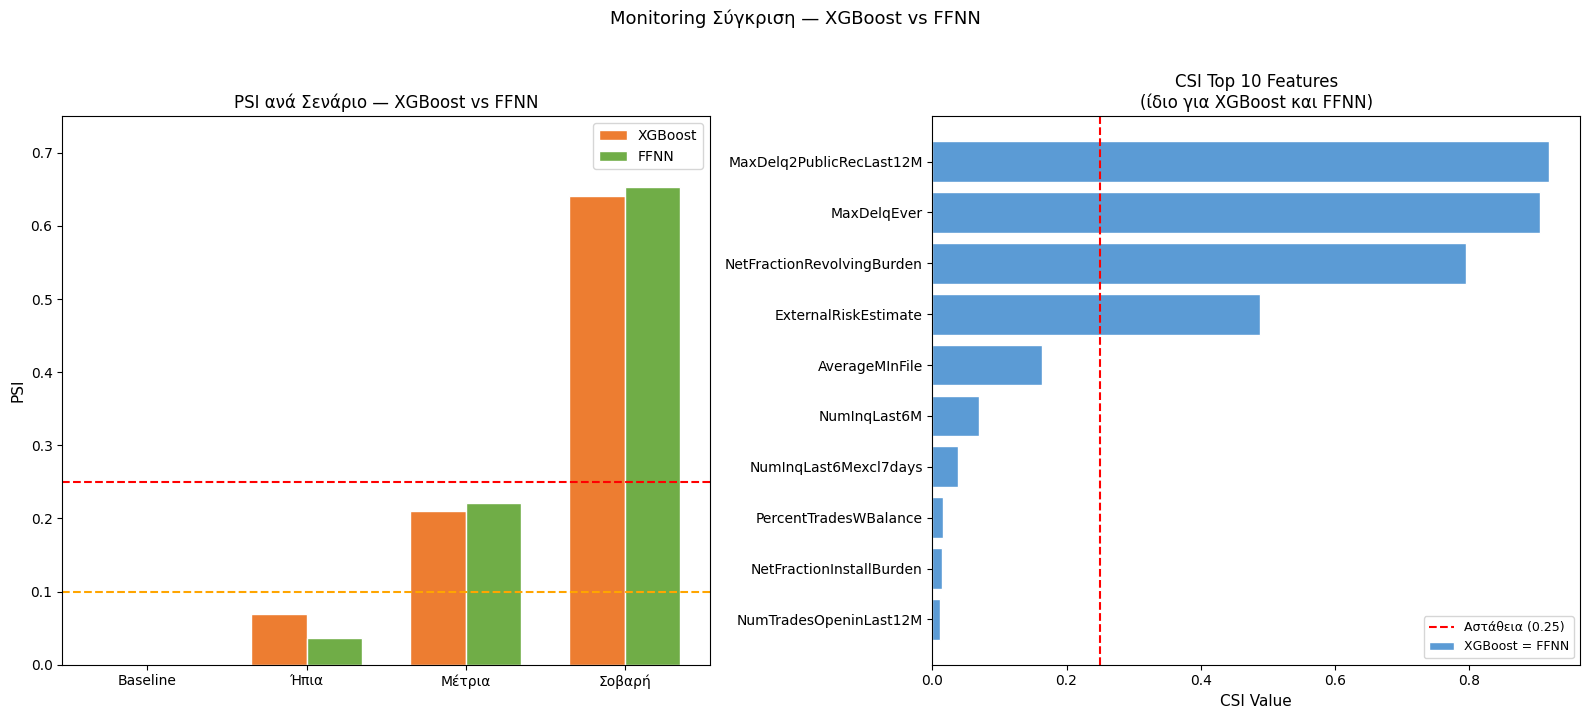

Αποθηκεύτηκε: figures/21_monitoring_comparison.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Γράφημα 1: PSI Scenarios σύγκριση
psi_df_xgb = pd.DataFrame([
    {'Σενάριο': 'Baseline', 'PSI': 0.0},
    {'Σενάριο': 'Ήπια', 'PSI': 0.069},
    {'Σενάριο': 'Μέτρια', 'PSI': 0.210},
    {'Σενάριο': 'Σοβαρή', 'PSI': 0.641}
])
psi_df_ffnn_plot = pd.DataFrame([
    {'Σενάριο': 'Baseline', 'PSI': 0.0},
    {'Σενάριο': 'Ήπια', 'PSI': 0.036},
    {'Σενάριο': 'Μέτρια', 'PSI': 0.221},
    {'Σενάριο': 'Σοβαρή', 'PSI': 0.653}
])

x = np.arange(4)
width = 0.35
axes[0].bar(x - width/2, psi_df_xgb['PSI'], width,
            label='XGBoost', color='#ed7d31', edgecolor='white')
axes[0].bar(x + width/2, psi_df_ffnn_plot['PSI'], width,
            label='FFNN', color='#70ad47', edgecolor='white')
axes[0].axhline(y=0.10, color='orange', linestyle='--', linewidth=1.5)
axes[0].axhline(y=0.25, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(psi_df_xgb['Σενάριο'])
axes[0].set_ylabel('PSI', fontsize=11)
axes[0].set_title('PSI ανά Σενάριο — XGBoost vs FFNN', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 0.75)

# Γράφημα 2: CSI σύγκριση top 10 features
top10 = csi_df.head(10)
x2 = np.arange(len(top10))
axes[1].barh(top10['Feature'][::-1], top10['CSI'][::-1],
             color='#5b9bd5', edgecolor='white', label='XGBoost = FFNN')
axes[1].axvline(x=0.25, color='red', linestyle='--', 
                linewidth=1.5, label='Αστάθεια (0.25)')
axes[1].set_xlabel('CSI Value', fontsize=11)
axes[1].set_title('CSI Top 10 Features\n(ίδιο για XGBoost και FFNN)', fontsize=12)
axes[1].legend(fontsize=9)

plt.suptitle('Monitoring Σύγκριση — XGBoost vs FFNN', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/21_monitoring_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: figures/21_monitoring_comparison.png")